In [1]:
!python --version

Python 3.11.13


# **GENERATING BARCODES**

In [22]:
import itertools #vr. 3.11.13
import random #vr. 3.11.13
import pandas as pd #vr. 2.2.3
import matplotlib.pyplot as plt #3.7.2
from tabulate import tabulate #v.0.9.0
from collections import Counter #vr. 3.11.13

def generate_candidates(length=8, alphabet='ACGT'): #ADJUST THE LENGTH OF THE BARCODES HERE
    return [''.join(p) for p in itertools.product(alphabet, repeat=length)]


def is_valid(seq, min_gc=0.40, max_gc=0.60, max_homo=3): # GC proportion ( Ideally the values must be 40-60%, but can be changed if necessary/required) 
                                                         # homopolymer limit can also be adjusted at "max_homo=" 
    gc = (seq.count('G') + seq.count('C')) / len(seq)
    if not (min_gc <= gc <= max_gc):
        return False
    for base in 'ACGT':
        if base * (max_homo + 1) in seq:
            return False
    if 'GGC' in seq:
        return False
    return True

def hamming_dist(s1, s2):
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))



candidates = [s for s in generate_candidates() if is_valid(s)]

#Hamming distance of choice (the minimum value should be 3, can be increased depending on the length of the barcode)
def select(cands, min_dist=3): 
    if not cands:
        return []
    
    barcodes = [cands[0]]
    
    for cand in cands[1:]:
        if all(hamming_dist(cand, b) >= min_dist for b in barcodes):
            barcodes.append(cand)
            
    return barcodes

barcodes = select(candidates)

print(f"Valid barcodes: {len(barcodes)}")

Valid barcodes: 756


# (1)Making sets 

In [3]:
#b4 making sets, the barcodes are shuffled :> since the generated barcodes are in kinda alphabetical order (in order)

random.shuffle(barcodes)

def Generated_sets(barcodes, size=96): #Default size of each sets to be generated is 96, but can be inc/dec accrodingly (48 if samples are low, 192 if excess)
    sets = []
    per_set = size * 2 #these barcodes are paired, since there are both forward and reverse barcodes.
    
    for i in range(0, len(barcodes), per_set):
        chunk = barcodes[i : i + per_set]
        
       
        if len(chunk) == per_set:
            pairs = []
            for j in range(0, len(chunk), 2):
                fwd = chunk[j]
                rev = chunk[j+1]
                pairs.append((fwd, rev)) #term "forward" and "reverse" are assigned to the sets
            sets.append(pairs)
            
    return sets
    

In [4]:
Sets = Generated_sets(barcodes)

#info on generated barcodes and total number of sets created 

print("Min distance:", min(hamming_dist(b1, b2) for i, b1 in enumerate(barcodes) 
                           for b2 in barcodes[i+1:]))
total_count = len(set(barcodes))
print(f"Total Unique Barcodes: {total_count}")

print(f"Total full 96-pair sets created: {len(Sets)}")

###number of sets generated and their first few barcode pairs###
for set_idx, pairs in enumerate(Sets):
    print(f"\n [SET {set_idx + 1}] ")
    for well_idx, (fwd, rev) in enumerate(pairs[:5]):
        print(f"  Well {well_idx + 1}: Forward={fwd}, Reverse={rev}")
    if len(pairs) > 5:
        print(f"  ... and {len(pairs) - 5} more pairs")

Min distance: 3
Total Unique Barcodes: 756
Total full 96-pair sets created: 3

 [SET 1] 
  Well 1: Forward=GATGTCGT, Reverse=GATCTCAG
  Well 2: Forward=TCGAAACC, Reverse=ATCCCTCT
  Well 3: Forward=GAGTGTTC, Reverse=CAACACGT
  Well 4: Forward=CGTCTCTA, Reverse=GTTCACCA
  Well 5: Forward=CAAGTCCA, Reverse=ACATGGTC
  ... and 91 more pairs

 [SET 2] 
  Well 1: Forward=ATTGGTCC, Reverse=GACCTGTA
  Well 2: Forward=CCTACTGA, Reverse=ACCAAGGT
  Well 3: Forward=GTGGTTTC, Reverse=TACCCAAC
  Well 4: Forward=CCACAGAT, Reverse=AATCCCTG
  Well 5: Forward=ACAGACAC, Reverse=TCCCGTTA
  ... and 91 more pairs

 [SET 3] 
  Well 1: Forward=ACCACCAA, Reverse=AGGACCTT
  Well 2: Forward=TGTACGGA, Reverse=ACTTCCGA
  Well 3: Forward=TCAAGCAC, Reverse=GATGCTAG
  Well 4: Forward=GGATTCCT, Reverse=TAACTCCG
  Well 5: Forward=AATCGGTC, Reverse=ATGTCGTG
  ... and 91 more pairs


# (2) Assigning sets 

In [5]:

Sets = {}
rows = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'] #barcodes in sets are arranged similar to a 96-well plate.
cols = range(1, 13)
wells = [f"{r}{c}" for r in rows for c in cols]

for i in range(3):
    start = i * 192
    end = start + 192
    chunk = barcodes[start:end]
    
    # classifications or columns  within the generated set (Well, Forward, Reverse).
    current_set = []
    for j in range(96):
        fwd = chunk[j*2]
        rev = chunk[j*2 + 1]
        current_set.append({'well': wells[j], 'fwd': fwd, 'rev': rev}) #VISUALIZE THE SET CONTENTS IN 3 SEPARATE COLUMNS
    
    Sets[f"set_{i+1}"] = current_set


def Set(set_variable, set_name="Barcode Set"):
    print(f"\n{set_name}")
    print(f"{'Well':<6} | {'Forward Barcode':<16} | {'Reverse Barcode':<16}")
    print("-" * 45)
    
    for entry in set_variable:
        print(f"{entry['well']:<6} | {entry['fwd']:<16} | {entry['rev']:<16}")

    return Set

set_number = 2 #Display custom set of choice, just change the set number(ez)
key = f"set_{set_number}"

if key in Sets:
    Set(Sets[key], f"Displaying {key}")
else:
    print("Set not found!")


Displaying set_2
Well   | Forward Barcode  | Reverse Barcode 
---------------------------------------------
A1     | ATTGGTCC         | GACCTGTA        
A2     | CCTACTGA         | ACCAAGGT        
A3     | GTGGTTTC         | TACCCAAC        
A4     | CCACAGAT         | AATCCCTG        
A5     | ACAGACAC         | TCCCGTTA        
A6     | GCATAACC         | GACACTCT        
A7     | ACTCTAGC         | CGAGGTAT        
A8     | CGTTTACC         | AAGCGGAT        
A9     | GGTTTCTC         | AAAGGTCG        
A10    | TAGCCACA         | TAGACGCT        
A11    | AAGCGTCA         | CCTCAATC        
A12    | AGTCGTCT         | CCGACATA        
B1     | CTAAGTCC         | AACCAGCA        
B2     | GAGCATAG         | AGCCTCTT        
B3     | AGAGTGGT         | CACAAAGC        
B4     | AAGGGTAC         | CACTACAC        
B5     | CGGATGAT         | CCCTATTC        
B6     | GACAAGGA         | ACGACGAT        
B7     | TGGTCGTT         | TGGGAACA        
B8     | TCGCGAAA         | GATACTGC

# **PROPORTION EVALUATION AT EACH POSITION**

In [6]:
def check_composition(set_data, set_label="Set"):
    barcode_length = len(set_data[0]['fwd'])
    num_pairs = len(set_data)
    
    # Soft N Hard Limits
    SOFT_MIN, SOFT_MAX = 15, 35
    HARD_MIN, HARD_MAX = 10, 60
    
    print(f"\n ^^^^ Nucleotide Composition: {set_label}^^^^")
    
    for direction in ['fwd', 'rev']:
        print(f"\n{direction.upper()} Barcode Positions (Indicators: S = Soft, H = Hard):")
        print(f"{'Pos':<5} | {'A%':<9} | {'C%':<9} | {'G%':<9} | {'T%':<9}")
        print("-" * 50)
        
        for pos in range(barcode_length):
            bases_at_pos = [entry[direction][pos] for entry in set_data]
            counts = {base: bases_at_pos.count(base) for base in "ACGT"}
            
           
            row_str = f"{pos:<5}"
            for base in "ACGT":
                pct = (counts[base] / num_pairs) * 100
                
                #Indication if the bases have hit the corresponding limits in each set :)
                flag = ""
                if pct < HARD_MIN or pct > HARD_MAX:  #Right next to each percentage, it indicates if the value has hit the soft/hard limit
                    flag = " H"
                elif pct < SOFT_MIN or pct > SOFT_MAX:
                    flag = " S"
                
                row_str += f" | {pct:>6.1f}%{flag:<2}"
            
            print(row_str)


check_composition(Sets["set_1"], "Set 1")
check_composition(Sets["set_2"], "Set 2")
check_composition(Sets["set_3"], "Set 3")  #Shows the composition of each set (upto 3 sets.). If there are more sets, duplicate this line and change the set numbers.


 ^^^^ Nucleotide Composition: Set 1^^^^

FWD Barcode Positions (Indicators: S = Soft, H = Hard):
Pos   | A%        | C%        | G%        | T%       
--------------------------------------------------
0     |   32.3%   |   28.1%   |   22.9%   |   16.7%  
1     |   34.4%   |   24.0%   |   27.1%   |   14.6% S
2     |   32.3%   |   20.8%   |   24.0%   |   22.9%  
3     |   30.2%   |   22.9%   |   26.0%   |   20.8%  
4     |   27.1%   |   25.0%   |   30.2%   |   17.7%  
5     |   34.4%   |   31.2%   |   18.8%   |   15.6%  
6     |   24.0%   |   31.2%   |   20.8%   |   24.0%  
7     |   31.2%   |   27.1%   |   19.8%   |   21.9%  

REV Barcode Positions (Indicators: S = Soft, H = Hard):
Pos   | A%        | C%        | G%        | T%       
--------------------------------------------------
0     |   26.0%   |   27.1%   |   28.1%   |   18.8%  
1     |   28.1%   |   26.0%   |   22.9%   |   22.9%  
2     |   34.4%   |   22.9%   |   17.7%   |   25.0%  
3     |   31.2%   |   22.9%   |   17.7%  

# (1)Visual representation of composition

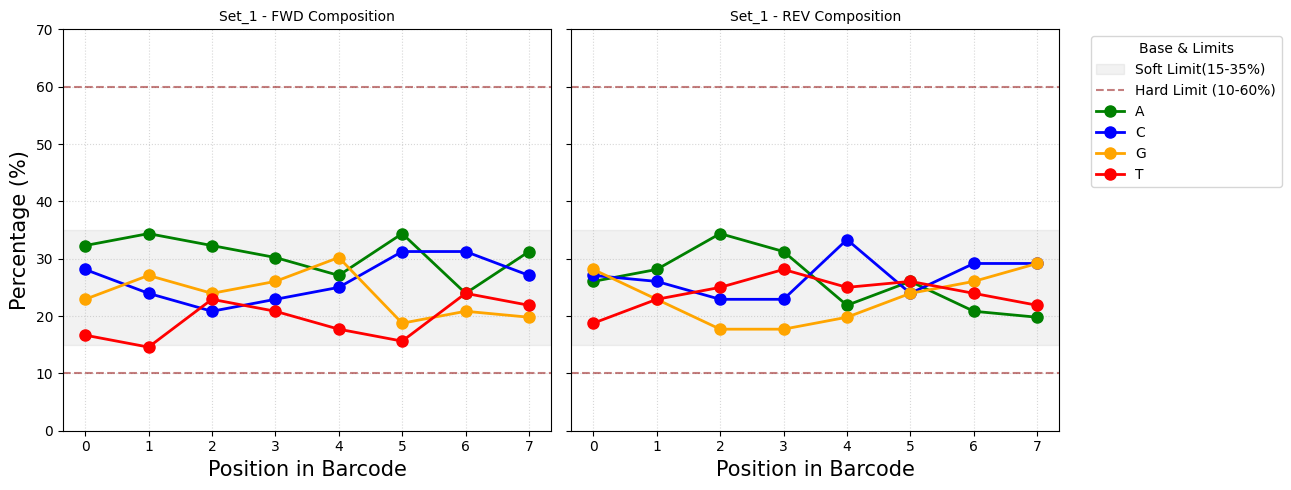

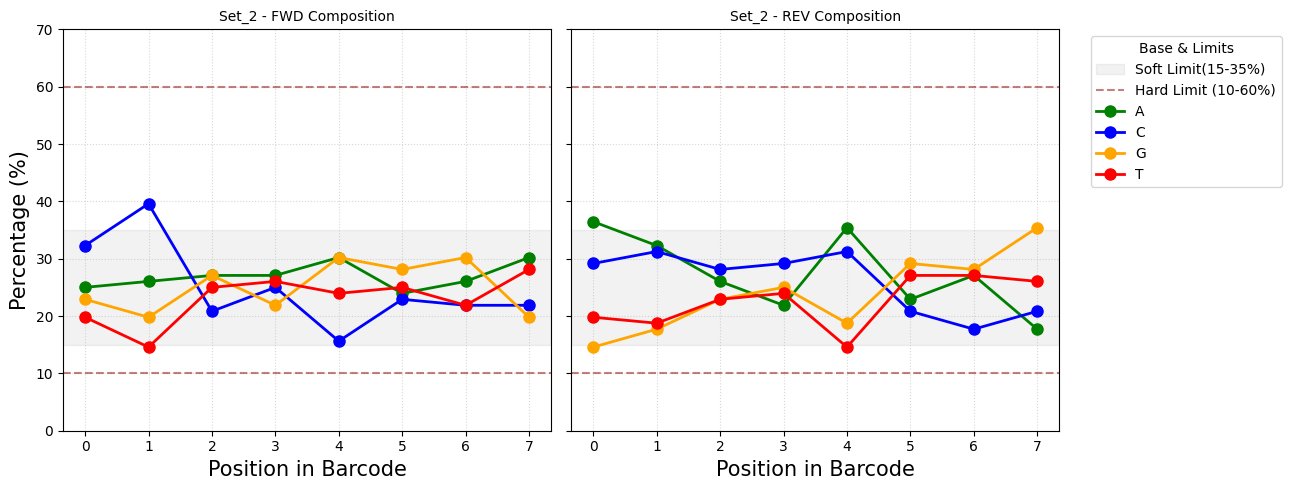

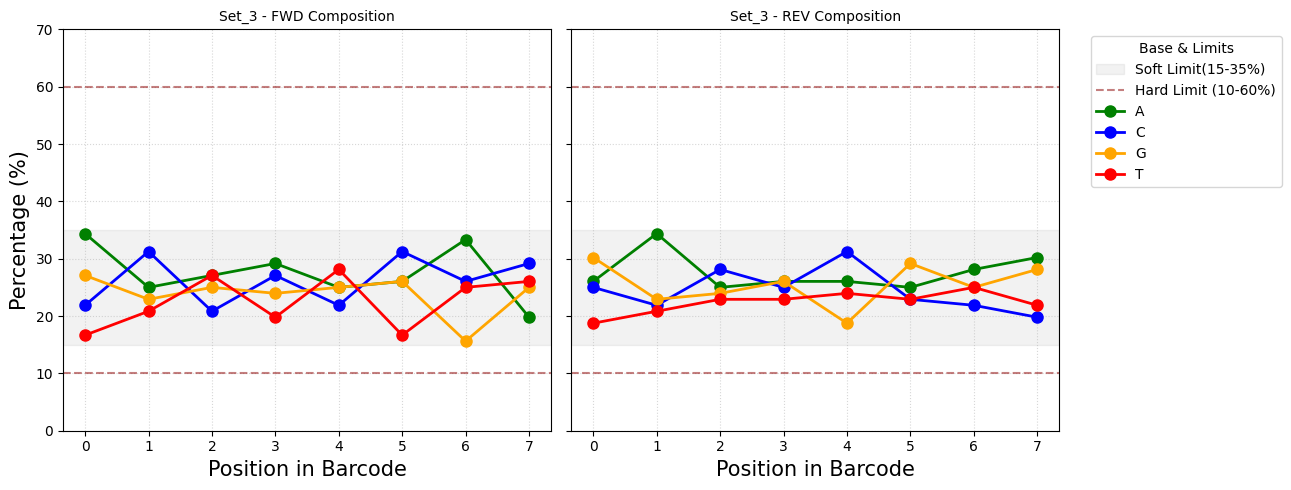

In [7]:
def plot_composition(set_data, set_label="Set 1"):
    barcode_length = len(set_data[0]['fwd'])
    num_pairs = len(set_data)
    
    bases = ['A', 'C', 'G', 'T']
    colors = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
    
    SOFT_MIN, SOFT_MAX = 15, 35
    HARD_MIN, HARD_MAX = 10, 60 #previously adapted limits
    
   
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    
    for i, direction in enumerate(['fwd', 'rev']):
        ax = axes[i] 
        percentages = {base: [] for base in bases}
        positions = list(range(barcode_length))
        
        for pos in positions:
            bases_at_pos = [entry[direction][pos] for entry in set_data]
            for base in bases:
                pct = (bases_at_pos.count(base) / num_pairs) * 100
                percentages[base].append(pct)
        

        ax.axhspan(SOFT_MIN, SOFT_MAX, color='gray', alpha=0.1, label='Soft Limit(15-35%)')
        ax.axhline(y=HARD_MAX, color='darkred', linestyle='--', alpha=0.5, label='Hard Limit (10-60%)')
        ax.axhline(y=HARD_MIN, color='darkred', linestyle='--', alpha=0.5)

        for base in bases:
            ax.plot(positions, percentages[base], label=base, 
                     color=colors[base], marker='o', linewidth=2, markersize=8)
        
        
        ax.set_title(f"{set_label} - {direction.upper()} Composition", fontsize=10)
        ax.set_xlabel("Position in Barcode", fontsize=15)
        if i == 0:  
            ax.set_ylabel("Percentage (%)", fontsize=15)
        
        ax.set_ylim(0, 70) 
        ax.set_xticks(positions)
        ax.grid(True, linestyle=':', alpha=0.5)
        
    
    axes[1].legend(title="Base & Limits", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


plot_composition(Sets["set_1"], "Set_1")
plot_composition(Sets["set_2"], "Set_2")
plot_composition(Sets["set_3"], "Set_3") #if there are more sets to visualize, duplicate this line and change the set number.

# **ROBUSTNESS**

# (1) Quality metric

In [8]:
def check_set_with_deviation(set_data, set_label="Set"):
    barcode_length = len(set_data[0]['fwd'])
    num_pairs = len(set_data)
    
   
    SOFT_MIN, SOFT_MAX = 15, 35
    HARD_MIN, HARD_MAX = 10, 60
    
    for direction in ['fwd', 'rev']:
        print(f"\n {set_label} ({direction.upper()})")
        
    
        header = f"{'Pos':<4} |  {'A%':<6}  {'C%':<6}  {'G%':<6}  {'T%':<6}| {'A.out':<6}  {'C.out':<6}  {'G.out':<6}  {'T.out':<6} | {'all_out'}"
        print(header)
        print("-" * 85)
        
        set_failed = False
        total_set_deviation = 0
        
        for pos in range(barcode_length):
            bases_at_pos = [entry[direction][pos] for entry in set_data]
            
           
            row_pcts = {base: (bases_at_pos.count(base) / num_pairs) * 100 for base in "ACGT"} #calculates the percentages of each bases at each position throughout the barcode length
            
           
            for pct in row_pcts.values():
                if pct < HARD_MIN or pct > HARD_MAX:
                    set_failed = True
            
            row_deviations = {}
            row_total_out = 0
            for base in "ACGT":
                val = row_pcts[base]
                dev = 0
                if val < SOFT_MIN:
                    dev = SOFT_MIN - val #calculates how much outside of the soft limit each of the percentages are
                elif val > SOFT_MAX:
                    dev = val - SOFT_MAX
                
                row_deviations[base] = dev
                row_total_out += dev
            
            total_set_deviation += row_total_out
            
            print(f"{pos:<4} |"
                  f"{row_pcts['A']:>5.1f}   {row_pcts['C']:>5.1f}   {row_pcts['G']:>5.1f}   {row_pcts['T']:>5.1f} | "
                  f"{row_deviations['A']:>5.1f}   {row_deviations['C']:>5.1f}   {row_deviations['G']:>5.1f}   {row_deviations['T']:>5.1f} | "
                  f"{row_total_out:>7.1f}")

       
        status = "Hard limit exceeded" if set_failed else "PASS"
        print("-" * 85)
        print(f"SET LIMIT CHECK : {status}")
        print(f"BASE DEVIATION : {total_set_deviation:.2f}\n")


check_set_with_deviation(Sets["set_1"], "Set 1")
check_set_with_deviation(Sets["set_2"], "Set 2")
check_set_with_deviation(Sets["set_3"], "Set 3")


 Set 1 (FWD)
Pos  |  A%      C%      G%      T%    | A.out   C.out   G.out   T.out  | all_out
-------------------------------------------------------------------------------------
0    | 32.3    28.1    22.9    16.7 |   0.0     0.0     0.0     0.0 |     0.0
1    | 34.4    24.0    27.1    14.6 |   0.0     0.0     0.0     0.4 |     0.4
2    | 32.3    20.8    24.0    22.9 |   0.0     0.0     0.0     0.0 |     0.0
3    | 30.2    22.9    26.0    20.8 |   0.0     0.0     0.0     0.0 |     0.0
4    | 27.1    25.0    30.2    17.7 |   0.0     0.0     0.0     0.0 |     0.0
5    | 34.4    31.2    18.8    15.6 |   0.0     0.0     0.0     0.0 |     0.0
6    | 24.0    31.2    20.8    24.0 |   0.0     0.0     0.0     0.0 |     0.0
7    | 31.2    27.1    19.8    21.9 |   0.0     0.0     0.0     0.0 |     0.0
-------------------------------------------------------------------------------------
SET LIMIT CHECK : PASS
BASE DEVIATION : 0.42


 Set 1 (REV)
Pos  |  A%      C%      G%      T%    | A.out   C

# (2) 10% of Barcodes removed from each set, and iterated 100 times to check the proportion 

In [9]:
def test_robustness(set_data, percentage, iterations=100):
    fail_count = 0
    num_to_keep = int(len(set_data) * (1 - percentage/100))
   
    sample_after_dropout = None 
    
    # Lists to store the extreme percentages for every iteration
    highest_per_iteration = []
    lowest_per_iteration = []

    for i in range(iterations):
        reduced = random.sample(set_data, num_to_keep)
        
        if i == 0:
            sample_after_dropout = reduced
            
        set_has_failed = False
        
        # Track the absolute highest and lowest base percentage found IN THIS ITERATION
        iter_max = 0.0
        iter_min = 100.0
        
        for direction in ['fwd', 'rev']:
            for pos in range(len(reduced[0]['fwd'])):
                bases = [item[direction][pos] for item in reduced]
                for b in "ACGT":
                    pct = (bases.count(b) / num_to_keep) * 100
                    
                    # Track extremes for the graph
                    if pct > iter_max:
                        iter_max = pct
                    if pct < iter_min:
                        iter_min = pct
                    
                    # Robustness threshold check (Hard limits)
                    if pct < 10 or pct > 60:
                        if not set_has_failed:
                            fail_count += 1
                            set_has_failed = True

        # Append this iteration's ultimate high and low to our history tracking
        highest_per_iteration.append(iter_max)
        lowest_per_iteration.append(iter_min)

    reliability = ((iterations - fail_count) / iterations) * 100
    
    return {
        "reliability": reliability,
        "sample_set": sample_after_dropout,
        "highest_history": highest_per_iteration,
        "lowest_history": lowest_per_iteration
    }

def plot_iteration_extremes(results_data, title_prefix):
    """
    Plots the highest and lowest nucleotide percentage found in each simulation iteration,
    including hard bounds (10%/60%) and soft limits (15%/35%).
    """
    iterations = range(1, len(results_data["highest_history"]) + 1)
    
    plt.figure(figsize=(13, 5))
    plt.plot(iterations, results_data["highest_history"], label="Highest Base %", color="crimson", alpha=0.7)
    plt.plot(iterations, results_data["lowest_history"], label="Lowest Base %", color="royalblue", alpha=0.7)
    
    # Hard Limits warning lines
    plt.axhline(y=60, color="darkred", linestyle="-.", alpha=0.6, label="Hard Max Bound (60%)")
    plt.axhline(y=10, color="darkred", linestyle="-.", alpha=0.6, label="Hard Min Bound (10%)")
    
    # Soft Limits warning lines
    plt.axhline(y=35, color="limegreen", linestyle=":", linewidth=1.5, alpha=0.7, label="Soft Max Limit (35%)")
    plt.axhline(y=15, color="limegreen", linestyle=":", linewidth=1.5, alpha=0.7, label="Soft Min Limit (15%)")
    
    plt.title(f"{title_prefix} - Nucleotide Extremes Across Iterations")
    plt.xlabel("Iteration Number")
    plt.ylabel("Nucleotide Percentage (%)")
    
    # Move legend outside or adjust opacity so it doesn't block data lines
    plt.legend(loc="upper right", framealpha=0.9)
    plt.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()


# **(3) Nucleotide composition after dropout of 10% of the barcodes from each set**

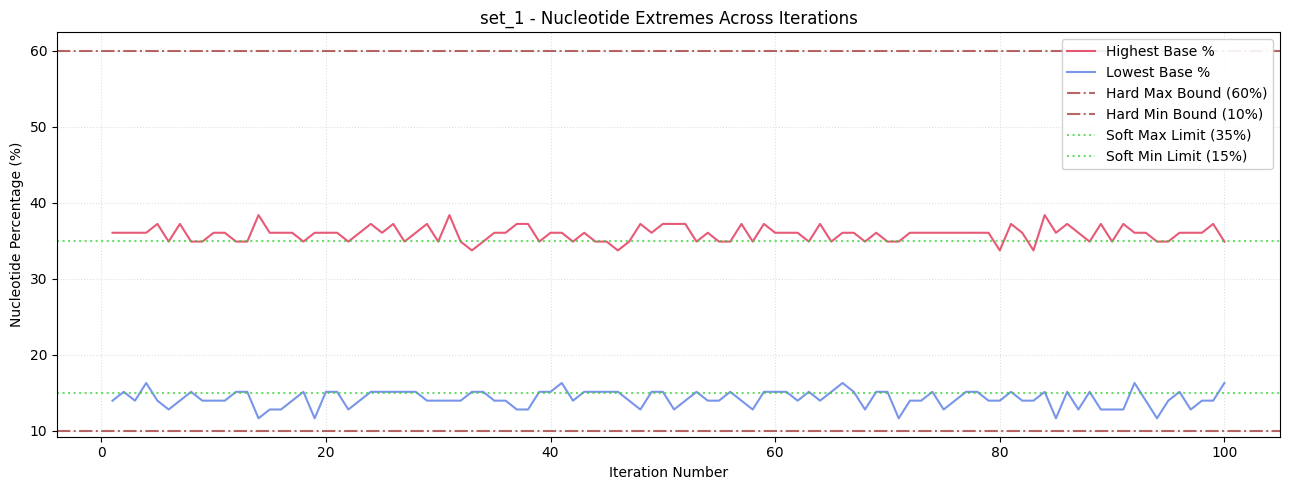

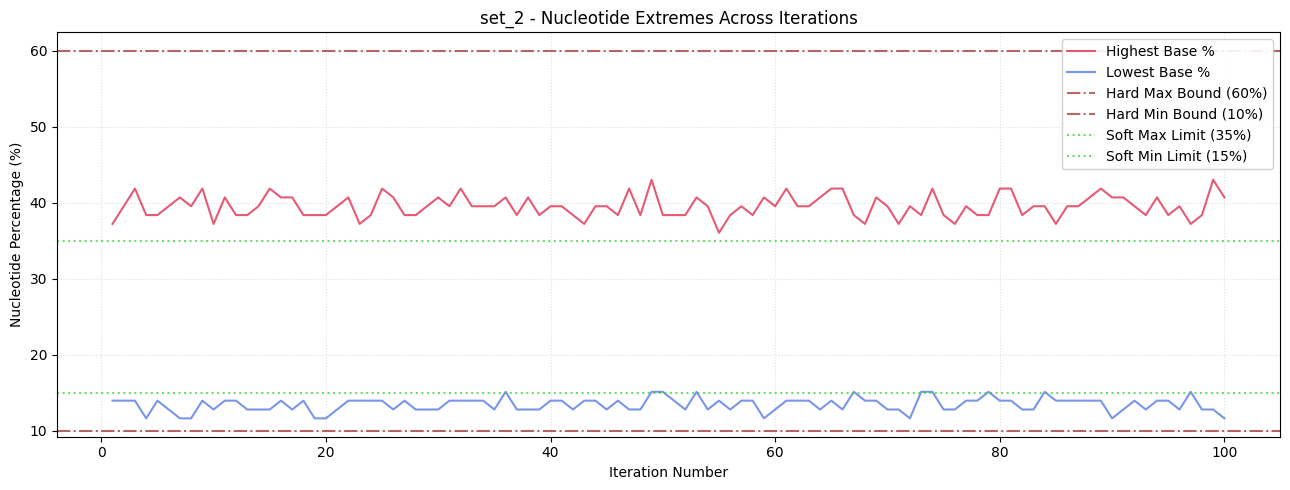

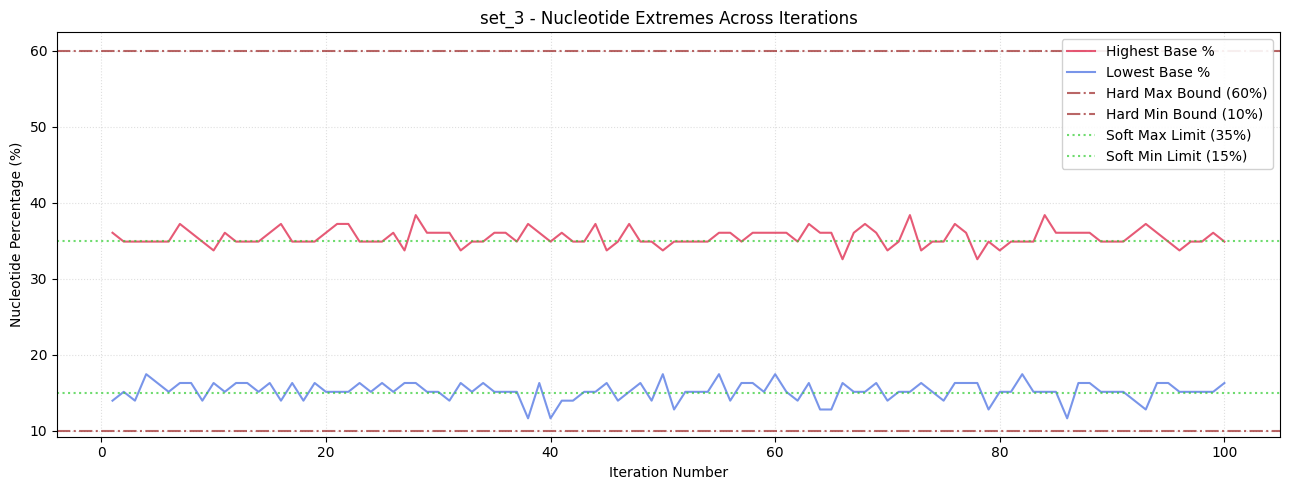

In [10]:
 #CHANGE THE PERCENTAGE OF BARCODE I NEED TO REMOVE AT "dropout_pct =" LINE. THE ABOVE CODE RUNS THE ITERATION 100 TIMES AND STORES THE SET
Results_Archive = {}
dropout_pct = 10 

# Run simulations
for set_id, barcode_list in Sets.items():
    Results_Archive[set_id] = test_robustness(barcode_list, dropout_pct)

# Plot both layouts
for set_id, data in Results_Archive.items():
       
    # New global extreme tracking plot across all iteration trials with soft/hard boundaries
    plot_iteration_extremes(data, set_id)

# **HOW MUCH PERCENTAGE OF BARCODE CAN BE REMOVED UNTIL THE SETS HIT THE HARD LIMITS**

# **HIGHLIGHTING THE CRITICAL BARCODES THAT CAUSE EARLY-HARD-LIMIT HIT** 

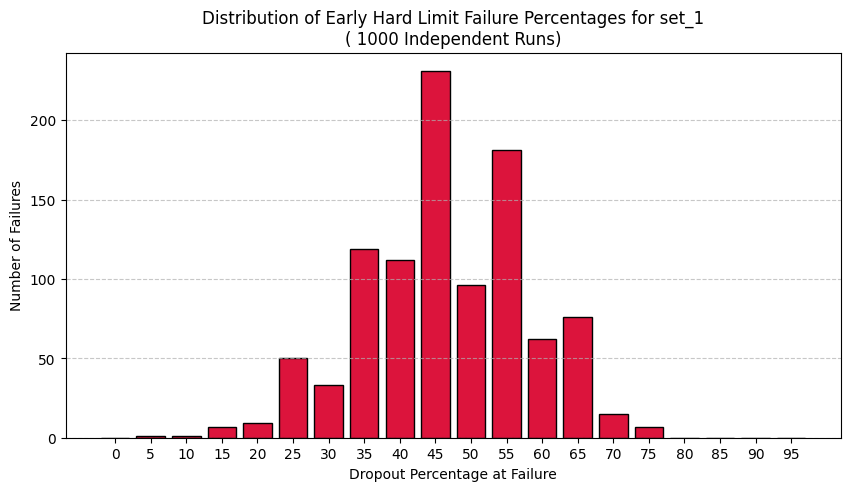

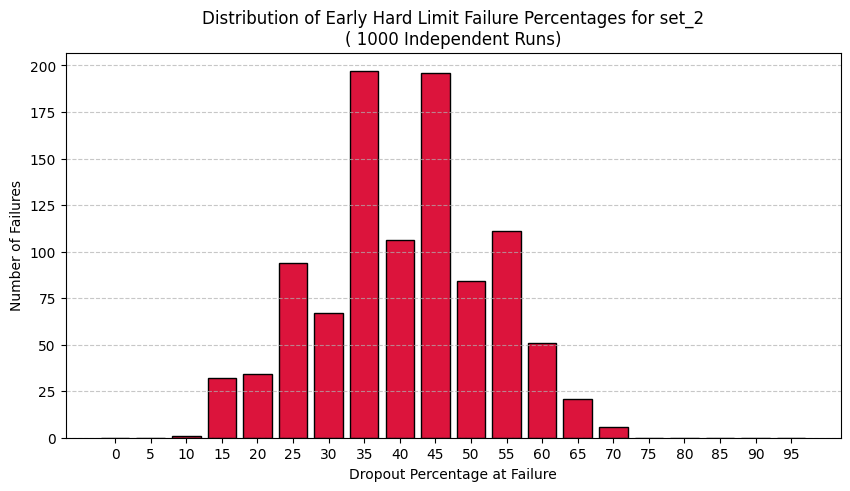

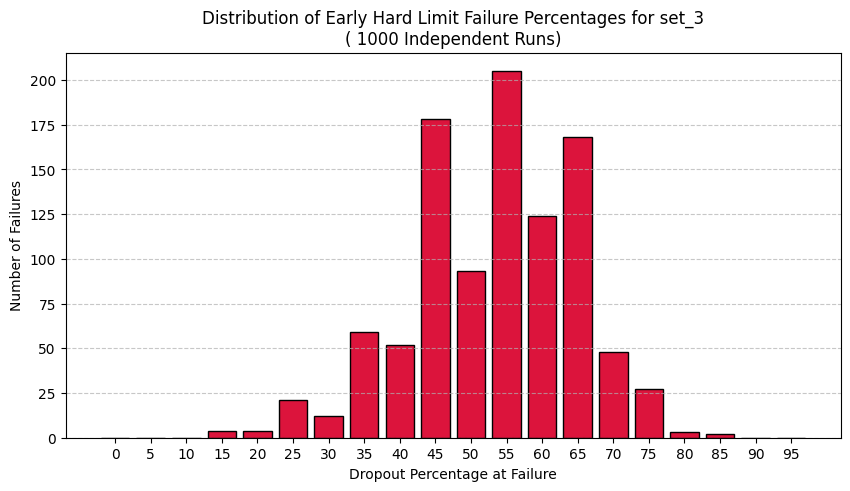


 CRITICAL BARCODE ANALYSIS 

Set: set_1
  The barcodes whose REMOVAL caused an early failure:
    - Barcode [TTCGACCA]: Removed in 2 early-failing sets
    - Barcode [TTGCCAAG]: Removed in 1 early-failing sets
    - Barcode [ATACGCCT]: Removed in 1 early-failing sets
    - Barcode [TTAACCCG]: Removed in 1 early-failing sets
    - Barcode [CTTGGATG]: Removed in 1 early-failing sets
    - Barcode [CGTCTCTA]: Removed in 1 early-failing sets
    - Barcode [TCTAGCCT]: Removed in 1 early-failing sets
    - Barcode [CTAAGCTG]: Removed in 1 early-failing sets
    - Barcode [GCATCAGA]: Removed in 1 early-failing sets
    - Barcode [CGCACAAT]: Removed in 1 early-failing sets
    - Barcode [CTCGAGAT]: Removed in 1 early-failing sets
    - Barcode [ATGTGTCG]: Removed in 1 early-failing sets
    - Barcode [ATCGGGTT]: Removed in 1 early-failing sets
    - Barcode [ATCGAACC]: Removed in 1 early-failing sets

Set: set_2
  The barcodes whose REMOVAL caused an early failure:
    - Barcode [CTAAGTCC]: R

In [11]:
#SIMULATION FUNCTION
def lim_test_single_run(reduced, num_to_keep):
    """
    Checks if a single reduced dataset breaches the 10% or 60% limits.
    Returns True if it FAILS (breaches limit), False if it PASSES.
    """
    for direction in ['fwd', 'rev']:
        for pos in range(len(reduced[0]['fwd'])):
            bases = [item[direction][pos] for item in reduced]
            for b in "ACGT":
                pct = (bases.count(b) / num_to_keep) * 100
                if pct < 10 or pct > 60:
                    return True # Failed the limit
    return False # Passed the limit


# MAIN RUNNER FOR 1000 ITERATIONS
# Data structures to hold your final analysis results
failure_dropout_distributions = {} 
critical_barcodes_summary = {}      

dropout_steps = range(0, 100, 5) 
sim_iterations = 1000

for set_id, barcode_list in Sets.items():
    
    failure_dropouts = []
    early_removed_barcodes = []
    
    for sim in range(sim_iterations):
        # increasing dropout levels are checked sequentially for this simulation run
        for pct in dropout_steps:
            num_to_keep = int(len(barcode_list) * (1 - pct/100))
            
            # If the dropout is so high that we can't sample anything, skip
            if num_to_keep <= 0:
                continue
                
            reduced = random.sample(barcode_list, num_to_keep)
            
            if lim_test_single_run(reduced, num_to_keep):
                # 1) Record the percentage at which it failed in this iteration
                failure_dropouts.append(pct)
                
                # 2) Identify critical barcodes if it's an early hitter (dropout <= 10%)
                if pct <= 10:
                    # Find which barcodes were removed (present in original, missing in reduced)
                    # Assumes your barcode items have a unique identifier like item['id'] or the object itself is hashable
                    reduced_ids = {id(item) for item in reduced} 
                    removed_items = [item for item in barcode_list if id(item) not in reduced_ids]
                    
                    for item in removed_items:
                        # Use a readable identifier. If 'name' or 'id' key doesn't exist, fallback to sequence string
                        identifier = item.get('id', item['fwd']) 
                        early_removed_barcodes.append(identifier)
                
                break # Stop checking higher dropouts for this specific iteration run
                
    failure_dropout_distributions[set_id] = failure_dropouts
    critical_barcodes_summary[set_id] = Counter(early_removed_barcodes)


# PLOTTING & ANALYSIS

# 1) Plot the distributions of failure points
for set_id, dropouts in failure_dropout_distributions.items():
    if not dropouts:
        print(f"{set_id} never failed in any of the 1000 runs.")
        continue
        
    plt.figure(figsize=(10, 5))
    # Using a histogram to visualize how frequently the set fails at each dropout stage
    plt.hist(dropouts, bins=[b - 2.5 for b in range(0, 105, 5)], rwidth=0.8, color='crimson', edgecolor='black')
    plt.title(f"Distribution of Early Hard Limit Failure Percentages for {set_id}\n( {sim_iterations} Independent Runs)")
    plt.xlabel("Dropout Percentage at Failure")
    plt.ylabel("Number of Failures")
    plt.xticks(dropout_steps)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# 2) Print the critical barcode analysis
print("\n CRITICAL BARCODE ANALYSIS ")
for set_id, counts in critical_barcodes_summary.items():
    print(f"\nSet: {set_id}")
    if not counts:
        print("  -> No early hard-limit hits (<= 10% dropout) occurred to show the barcodes.")
    else:
        print("  The barcodes whose REMOVAL caused an early failure:")
        for barcode, count in counts.most_common():
            print(f"    - Barcode [{barcode}]: Removed in {count} early-failing sets")

# **NUMBER OF BARCODES BEING GENERATED AT A LENGTH OF 9 AND 10 BASES** 

In [12]:
def length_9(length=9, alphabet='ACGT'): #ADJUST THE LENGTH OF THE BARCODES HERE
    return [''.join(p) for p in itertools.product(alphabet, repeat=length)]


def is_valid(seq, min_gc=0.40, max_gc=0.60, max_homo=3): 
    gc = (seq.count('G') + seq.count('C')) / len(seq)
    if not (min_gc <= gc <= max_gc):
        return False
    for base in 'ACGT':
        if base * (max_homo + 1) in seq:
            return False
    if 'GGC' in seq:
        return False
    return True

def hamming_dist(s1, s2):
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))



selected = [s for s in length_9() if is_valid(s)]

def select(cands, min_dist=3): 
    if not cands:
        return []
    
    barcodes = [cands[0]]
    
    for cand in cands[1:]:
        if all(hamming_dist(cand, b) >= min_dist for b in barcodes):
            barcodes.append(cand)
            
    return barcodes

barcodes = select(selected)

print(f"Valid barcodes: {len(barcodes)}")

KeyboardInterrupt: 

In [ ]:
def length_10(length=10, alphabet='ACGT'): #ADJUST THE LENGTH OF THE BARCODES HERE
    return [''.join(p) for p in itertools.product(alphabet, repeat=length)]


def is_valid(seq, min_gc=0.40, max_gc=0.60, max_homo=3): 
    gc = (seq.count('G') + seq.count('C')) / len(seq)
    if not (min_gc <= gc <= max_gc):
        return False
    for base in 'ACGT':
        if base * (max_homo + 1) in seq:
            return False
    if 'GGC' in seq:
        return False
    return True

def hamming_dist(s1, s2):
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))



selected = [s for s in length_10() if is_valid(s)]

def select(cands, min_dist=3): 
    if not cands:
        return []
    
    barcodes = [cands[0]]
    
    for cand in cands[1:]:
        if all(hamming_dist(cand, b) >= min_dist for b in barcodes):
            barcodes.append(cand)
            
    return barcodes

barcodes = select(selected)

print(f"Valid barcodes: {len(barcodes)}")